In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp1d
from tabulate import tabulate
import os
import copy
import re
from collections import defaultdict
from scipy.spatial import cKDTree
from scipy.spatial import distance
from math import isclose
from scipy import interpolate
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.integrate import trapz
from scipy.integrate import quad
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from scipy.spatial import QhullError

# DEFINING MY FUNCTIONS

**POLARIZATION DEGREE & ANGLE FUNCTIONS**

In [2]:
# Equations to calculate the polarization degree and angle

def polarization_degree(i,q,u):
    return np.sqrt(q**2+u**2)/i

def polarization_angle(q,u):
    return 0.5*np.rad2deg(np.arctan(u/q))

**BLACKBODY INTENSITY FUNCTION**

In [3]:
def blackbody_intensity_keV(energy_keV, temperature_K):
    k_B_keV = 8.617333262145e-5  # Boltzmann constant in keV/K
    kT = k_B_keV * temperature_K
    intensity = (energy_keV**3) / (np.exp(energy_keV / kT) - 1)
    return intensity

**DATA LOADING/READING FUNCTIONS**

In [4]:
# Function to read the data file and store all of the data for each cosT and Phi value in a dictionary

def read_res_file(file_path):
    data_dict = defaultdict(dict)
    current_cosT = None
    current_P = None
    data_list = []

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()

            # Detect new cosT and P block
            if "cosT" in line:    
                # Store previous data block
                if current_cosT is not None and current_P is not None and data_list:
                    data_dict[current_cosT][current_P] = pd.DataFrame(data_list, columns=["Energy", "Value"])
                
                # Extract cosT and P
                parts = line.split()
                current_cosT = float(parts[1])
                current_P = float(parts[3]) if "#P" in parts else None
                data_list = []

            else:
                parts = line.split()
                if len(parts) == 2:
                    try:
                        x, y = map(float, parts)
                        data_list.append((x, y))
                    except ValueError:
                        pass

    # Store last section
    if current_cosT is not None and current_P is not None and data_list:
        data_dict[current_cosT][current_P] = pd.DataFrame(data_list, columns=["Energy", "Value"])

    return data_dict

**GLOBAL FUNCTIONS USED**

In [5]:
def spherical_to_cartesian(theta_deg, phi_deg):
    """Converts spherical (theta, phi) in degrees to a cartesian 3D unit vector."""
    theta = np.radians(theta_deg)
    phi = np.radians(phi_deg)
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    return np.array([x, y, z])


def cartesian_to_spherical(vec):
    """Converts a cartesian vector to spherical (theta, phi) in degrees."""
    x, y, z = vec
    r = np.linalg.norm(vec)
    theta = np.degrees(np.arccos(z / r))
    phi = np.degrees(np.arctan2(y, x)) % 360
    return theta, phi

**FORWARD PROCESS FUNCTIONS**

In [6]:
# FORWARD PROCESS. phi_s is obtained using the projection of the global z-axis as the reference direction

def local_angles_to_global_z_ref(theta_wind, phi_wind, theta_local, phi_local):
    # 1. Wind direction vector in global coordinates
    wind_vec = spherical_to_cartesian(theta_wind, phi_wind)

    # 2. Define local direction (obs direction in local frame)
    local_vec = spherical_to_cartesian(theta_local, 0)  # initially pointing along the local xz-plane

    # 3. Project global z-axis onto wind-perpendicular plane (same as in the reverse process)
    z_axis = np.array([0, 0, 1])
    z_proj = z_axis - np.dot(z_axis, wind_vec) * wind_vec
    z_proj /= np.linalg.norm(z_proj)

    # 4. Create right-handed local basis: z_proj (x'), wind_vec x z_proj (y'), wind_vec (z')
    x_local = z_proj
    y_local = np.cross(wind_vec, z_proj)
    y_local /= np.linalg.norm(y_local)
    z_local = wind_vec

    # 5. Build rotation matrix: from local basis to global basis
    R = np.column_stack([x_local, y_local, z_local])  # local-to-global frame

    # 6. Rotate local_vec around local z-axis by phi_local to get final direction in local frame
    phi_local_rad = np.radians(phi_local)
    rot_z = np.array([
        [np.cos(phi_local_rad), -np.sin(phi_local_rad), 0],
        [np.sin(phi_local_rad),  np.cos(phi_local_rad), 0],
        [0,                     0,                      1]
    ])
    rotated_local_vec = rot_z @ local_vec

    # 7. Convert to global coordinates using basis
    global_vec = R @ rotated_local_vec                   # @ = matrix multiplication

    # 8. Convert back to spherical
    theta_system, phi_system = cartesian_to_spherical(global_vec)
    return theta_system, phi_system



theta_wind = 15
phi_wind = 0
theta_local = 15   # This is essentially theta_s
phi_local = 180    # This is essentially phi_s


# Note: theta_system and phi_system are essentially theta_obs and phi_obs respectively
theta_system, phi_system = local_angles_to_global_z_ref(theta_wind, phi_wind, theta_local, phi_local)
print("Theta_system =", round(theta_system, 8), "Phi_system =", round(phi_system, 8))

Theta_system = 30.0 Phi_system = 360.0


**REVERSE PROCESS FUNCTIONS**

In [7]:
# REVERSE PROCESS. phi_s is obtained using the projection of the global z-axis as the reference direction

def observer_to_local_cosT_P_z_ref(theta_obs, phi_obs, theta_wind, phi_wind):
    phi_obs = phi_obs % 360
    # Convert to radians
    theta_obs_rad = np.radians(theta_obs)
    phi_obs_rad = np.radians(phi_obs)
    theta_wind_rad = np.radians(theta_wind)
    phi_wind_rad = np.radians(phi_wind)

    # Observer vector in the system frame
    obs_vec = spherical_to_cartesian(theta_obs, phi_obs)

    # Wind vector in the system frame
    wind_vec = spherical_to_cartesian(theta_wind, phi_wind)

    # cos(theta_s) = cos(theta_local) calculated using equation (12) from Taverna et al. 2015
    cosT_s = (
            np.cos(theta_obs_rad) * np.cos(theta_wind_rad)
            + np.sin(theta_obs_rad) * np.sin(theta_wind_rad) * np.cos(phi_obs_rad - phi_wind_rad)
            )

    # Define the plane perpendicular to the wind direction and use global z-axis as reference vector to project
    z_axis = np.array([0, 0, 1])
    z_proj = z_axis - np.dot(z_axis, wind_vec) * wind_vec  # project z onto the wind-perpendicular plane
    z_proj /= np.linalg.norm(z_proj)

    # Project obs_vec into same perpendicular plane (same as the forward process)
    obs_proj = obs_vec - np.dot(obs_vec, wind_vec) * wind_vec
    obs_proj_norm = np.linalg.norm(obs_proj)
    
    if obs_proj_norm < 1e-8:
        phi_s = 0.0  # Arbitrarily define when projection is zero (fully aligned)
    else:
        obs_proj /= obs_proj_norm

    # Get azimuthal angle phi_s relative to projected z-axis
    # Use arctan2 to determine angle between projections = phi_s
    x = np.dot(obs_proj, z_proj)  # dot with projected z-axis
    y = np.dot(obs_proj, np.cross(wind_vec, z_proj))  # dot with orthogonal vector (right-handed)
    phi_s = np.degrees(np.arctan2(y, x)) % 360  # ensure phi_s is between 0 and 360

    return cosT_s, phi_s



theta_obs = 30
phi_obs = 0
theta_wind = 15
phi_wind = 0

cosT_local, P_local = observer_to_local_cosT_P_z_ref(theta_obs, phi_obs, theta_wind, phi_wind)
print(f"cosT_local = {cosT_local:.3f}, P_local = {P_local:.3f}")
print("Theta_local = ", round(np.degrees(np.arccos(cosT_local)), 5))

cosT_local = 0.966, P_local = 180.000
Theta_local =  15.0


**Comparing both processes**

In [8]:
# COMPARISON OF FUNCTIONS WITH phi_s DEFINED USING THE PROJECTION OF THE GLOBAL Z-AXIS AS THE REFERENCE DIRECTION

theta_obs = 30
phi_obs = 50
theta_wind = 45
phi_wind = 135

# Reverse: system to local
cosT_local, phi_local = observer_to_local_cosT_P_z_ref(theta_obs, phi_obs, theta_wind, phi_wind)
theta_local = np.degrees(np.arccos(cosT_local))

# Forward: local to system
theta_obs_recovered, phi_obs_recovered = local_angles_to_global_z_ref(theta_wind, phi_wind, theta_local, phi_local)


print(f"Original:  theta = {theta_obs:.5f}, phi = {phi_obs:.5f}")
print(f"Intermediate: cosT_local = {cosT_local:.5f}, Theta_local = {theta_local:.5f}, phi_local = {phi_local:.5f}")
print(f"Recovered: theta = {theta_obs_recovered:.5f}, phi = {phi_obs_recovered:.5f}")

Original:  theta = 30.00000, phi = 50.00000
Intermediate: cosT_local = 0.64319, Theta_local = 49.97015, phi_local = 40.57964
Recovered: theta = 30.00000, phi = 50.00000


**Plotting functions**

In [20]:
# Function to plot the plots I want for a single chosen Phi value (just to see if I and PolDeg order is right)
# These plots are for BEFORE integration

def plot_stokes_results(results_list, observer_labels, show_blackbody=False, temperature_K=10**7):
    fig, axes = plt.subplots(3, 1, figsize=(10, 16), sharex=True)
    
    # Colormap setup
    cmap = plt.colormaps["turbo_r"].resampled(len(observer_labels))
    colors = [cmap(i) for i in range(len(observer_labels))]
    
    # Grab energy values for the blackbody curve
    energy_common = results_list[0]["Energy"]

    for idx, (result_df, label) in enumerate(zip(results_list, observer_labels)):
        energy = result_df["Energy"]
        I = result_df["I"]
        Q = result_df["Q"]
        U = result_df["U"]
        P_Degree = result_df["P_Degree"]
        P_Angle = result_df["P_Angle"]
        
        color = colors[idx]

        axes[0].plot(energy, I, color=color, marker='o', linestyle='-', markersize=0, label=label)
        #axes[1].plot(energy, Q, color=color, marker='o', linestyle='-', markersize=0, label=label)
        #axes[2].plot(energy, U, color=color, marker='o', linestyle='-', markersize=0, label=label)
        axes[1].plot(energy, P_Degree, color=color, marker='o', linestyle='-', markersize=0, label=label)
        axes[2].plot(energy, P_Angle, color=color, marker='o', linestyle='-', markersize=0, label=label)
    
    # --- NEW ADDITION: Normalize BB curve using lowest inclination ---
    # Find the index of the lowest inclination automatically
    # Extract numeric angle from each label safely
    angles = []
    for label in observer_labels:
        match = re.search(r"[-+]?\d*\.?\d+", label)  # extract first number in string
        if match:
            angles.append(float(match.group()))
        else:
            raise ValueError(f"Could not find numeric angle in label: {label}")

    lowest_idx = np.argmin(angles)
    #lowest_idx = np.argmin([float(label.split()[0]) for label in observer_labels])
    max_I_lowest = max(results_list[lowest_idx]["I"])

    # Add blackbody overlay
    if show_blackbody:
        bb_I = blackbody_intensity_keV(energy_common, temperature_K)
        # Normalize blackbody intensity to match max intensity of lowest inclination
        bb_I_scaled = bb_I / np.max(bb_I) * max_I_lowest
        axes[0].plot(energy_common, bb_I_scaled, linestyle='--', color='black', label=f'Blackbody T={temperature_K:.1e}K')
    
    # Add blackbody overlay
    #if show_blackbody:
        #bb_I = blackbody_intensity_keV(energy_common, temperature_K)
        # Normalize for comparison (optional)
        #bb_I_scaled = bb_I / np.max(bb_I) * max(result_df["I"])   # CHANGE TO NORMALIZE WITH 12 DEGREE INTENSITY
        #axes[0].plot(energy_common, bb_I_scaled, linestyle='--', color='black', label=f'Blackbody T={temperature_K:.1e}K')
    
    
    # Add vertical dotted lines at 2000 and 8000 eV (IXPE energy range)
    for ax in axes:
        ax.axvline(x=2000, color='black', linestyle=':', linewidth=1.5)
        ax.axvline(x=8000, color='black', linestyle=':', linewidth=1.5)
    
    # Format I plot
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_ylabel("I (Intensity)", fontsize=15)
    axes[0].set_title("I vs Energy", fontsize=16)
    axes[0].grid(True)
    axes[0].legend(fontsize=12)
    
    # Format Q plot
    #axes[1].set_xscale('log')
    #axes[1].set_yscale('log')
    #axes[1].set_ylabel("Q", fontsize=15)
    #axes[1].set_title("Q vs Energy", fontsize=16)
    #axes[1].grid(True)
    #axes[1].legend(fontsize=12)
    
    # Format U plot
    #axes[2].set_xscale('log')
    #axes[2].set_yscale('log')
    #axes[2].set_ylabel("U", fontsize=15)
    #axes[2].set_title("U vs Energy", fontsize=16)
    #axes[2].grid(True)
    #axes[2].legend(fontsize=12)

    # Format P_Degree plot
    axes[1].set_xscale('log')
    axes[1].set_ylabel(r"$\Pi$", fontsize=18)
    axes[1].set_title("Polarization Degree vs Energy", fontsize=16)
    axes[1].grid(True)
    axes[1].legend(fontsize=12)

    # Format P_Angle plot
    axes[2].set_xscale('log')
    axes[2].set_ylim(-10, 100)
    axes[2].set_ylabel(r"$X$ (degrees)", fontsize=18)
    axes[2].set_xlabel("Energy", fontsize=15)
    axes[2].set_title("Polarization Angle vs Energy", fontsize=16)
    axes[2].grid(True)
    axes[2].legend(fontsize=12)

    plt.tight_layout()
    plt.show()

# LOADING ALL OF THE DATA IN

In [10]:
# Degree values I want to use
degree_values = [12, 24, 36, 48, 60, 72, 84]


# Base file path template
base_template = "./output_stokes_1e10_summed/{deg}deg/MissingSIM_24._Photo_BB.sh_T6.8144579_d17._{stokes}.res"

all_files = {}          # Holds paths to I/Q/U files per degree
all_res_data = {}       # Holds raw res file data per degree
all_merged_data = {}    # Holds merged DataFrames per degree


for deg in degree_values:
    # Set up I/Q/U file paths for this degree
    files_deg = {
        stokes: base_template.format(deg=deg, stokes=stokes)
        for stokes in ["I", "Q", "U"]
    }
    all_files[deg] = files_deg

    # Load the RES data for this degree
    res_data = {key: read_res_file(path) for key, path in files_deg.items()}
    all_res_data[deg] = res_data

    # Merge the I/Q/U data per (cosT, P) pair
    merged_data = {}
    for cosT in res_data["I"]:
        for P in res_data["I"][cosT]:
            df_I = res_data["I"][cosT][P].rename(columns={"Value": "I"})
            df_Q = res_data["Q"][cosT][P].rename(columns={"Value": "Q"})
            df_U = res_data["U"][cosT][P].rename(columns={"Value": "U"})

            merged_df = df_I.merge(df_Q, on="Energy").merge(df_U, on="Energy")
            
            # Add polarization degree and angle
            merged_df["P_Degree"] = polarization_degree(merged_df["I"], merged_df["Q"], merged_df["U"])
            merged_df["P_Angle"] = polarization_angle(merged_df["Q"], merged_df["U"])
            
            merged_data[(cosT, P)] = merged_df

    all_merged_data[deg] = merged_data


# Normalize the 84deg dataset (I,Q,U) because it has 5 times more photons (5e+10 instead of 1e+10)
if 84 in all_merged_data:
    for (cosT, P), df in all_merged_data[84].items():
        df[["I", "Q", "U"]] /= 5  # scale down intensity and polarization
        df["P_Degree"] = polarization_degree(df["I"], df["Q"], df["U"])  # optional recompute
        df["P_Angle"] = polarization_angle(df["Q"], df["U"])
    
# Load all of the data needed for plotting from 12 to 84 degrees

merged_12deg_data = all_merged_data[12]
merged_24deg_data = all_merged_data[24]
merged_36deg_data = all_merged_data[36]
merged_48deg_data = all_merged_data[48]
merged_60deg_data = all_merged_data[60]
merged_72deg_data = all_merged_data[72]
merged_84deg_data = all_merged_data[84]

In [11]:
degree_values_test = list(all_merged_data.keys())
print(degree_values_test)

[12, 24, 36, 48, 60, 72, 84]


In [12]:
# Same for all inclination angles so just using 12deg as an example
print(f"Keys in all_merged_data[{degree_values[0]}]: {list(all_merged_data[degree_values[0]].keys())[:]}")

Keys in all_merged_data[12]: [(0.95, 30.0), (0.95, 90.0), (0.95, 150.0), (0.95, 210.0), (0.95, 270.0), (0.95, 330.0), (0.85, 30.0), (0.85, 90.0), (0.85, 150.0), (0.85, 210.0), (0.85, 270.0), (0.85, 330.0), (0.75, 30.0), (0.75, 90.0), (0.75, 150.0), (0.75, 210.0), (0.75, 270.0), (0.75, 330.0), (0.65, 30.0), (0.65, 90.0), (0.65, 150.0), (0.65, 210.0), (0.65, 270.0), (0.65, 330.0), (0.55, 30.0), (0.55, 90.0), (0.55, 150.0), (0.55, 210.0), (0.55, 270.0), (0.55, 330.0), (0.45, 30.0), (0.45, 90.0), (0.45, 150.0), (0.45, 210.0), (0.45, 270.0), (0.45, 330.0), (0.35, 30.0), (0.35, 90.0), (0.35, 150.0), (0.35, 210.0), (0.35, 270.0), (0.35, 330.0), (0.25, 30.0), (0.25, 90.0), (0.25, 150.0), (0.25, 210.0), (0.25, 270.0), (0.25, 330.0), (0.15, 30.0), (0.15, 90.0), (0.15, 150.0), (0.15, 210.0), (0.15, 270.0), (0.15, 330.0), (0.05, 30.0), (0.05, 90.0), (0.05, 150.0), (0.05, 210.0), (0.05, 270.0), (0.05, 330.0)]


# Getting the Theta & Phi values

In [13]:
# Get all unique cosT values from my merged_12deg_data (same as any merged_*deg_data)
unique_cosT_values = sorted(set(cosT for (cosT, _) in merged_12deg_data.keys()))

# Convert to theta (T) values in degrees
theta_values = [round(np.degrees(np.arccos(cosT)),4) for cosT in unique_cosT_values]  # Can change decimal rounding here

phi_values = [30, 90, 150, 210, 270, 330]

# Print the result
print("cosT values:", unique_cosT_values)
print("T (theta) values in degrees:", theta_values)
print("P (phi) values in degrees:", phi_values)

cosT values: [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]
T (theta) values in degrees: [87.134, 81.3731, 75.5225, 69.5127, 63.2563, 56.633, 49.4584, 41.4096, 31.7883, 18.1949]
P (phi) values in degrees: [30, 90, 150, 210, 270, 330]


# INTEGRATING (I,Q,U) FOR CHOSEN OBSERVER POSITIONS (DISCRETE PHI)

**REVERSE PROCESS**

Computing for θ = 15, φ = 0

[REVERSE] Processing phi_wind = 0.0
Finished wind phi angle 0.0 degrees

[REVERSE] Processing phi_wind = 3.6
Finished wind phi angle 3.6 degrees

[REVERSE] Processing phi_wind = 7.2
Finished wind phi angle 7.2 degrees

[REVERSE] Processing phi_wind = 10.8
Finished wind phi angle 10.8 degrees

[REVERSE] Processing phi_wind = 14.4
Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[R

Finished wind phi angle 3.6 degrees

[REVERSE] Processing phi_wind = 7.2
Finished wind phi angle 7.2 degrees

[REVERSE] Processing phi_wind = 10.8
Finished wind phi angle 10.8 degrees

[REVERSE] Processing phi_wind = 14.4
Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4


Finished wind phi angle 10.8 degrees

[REVERSE] Processing phi_wind = 14.4
Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57

Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64

Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72

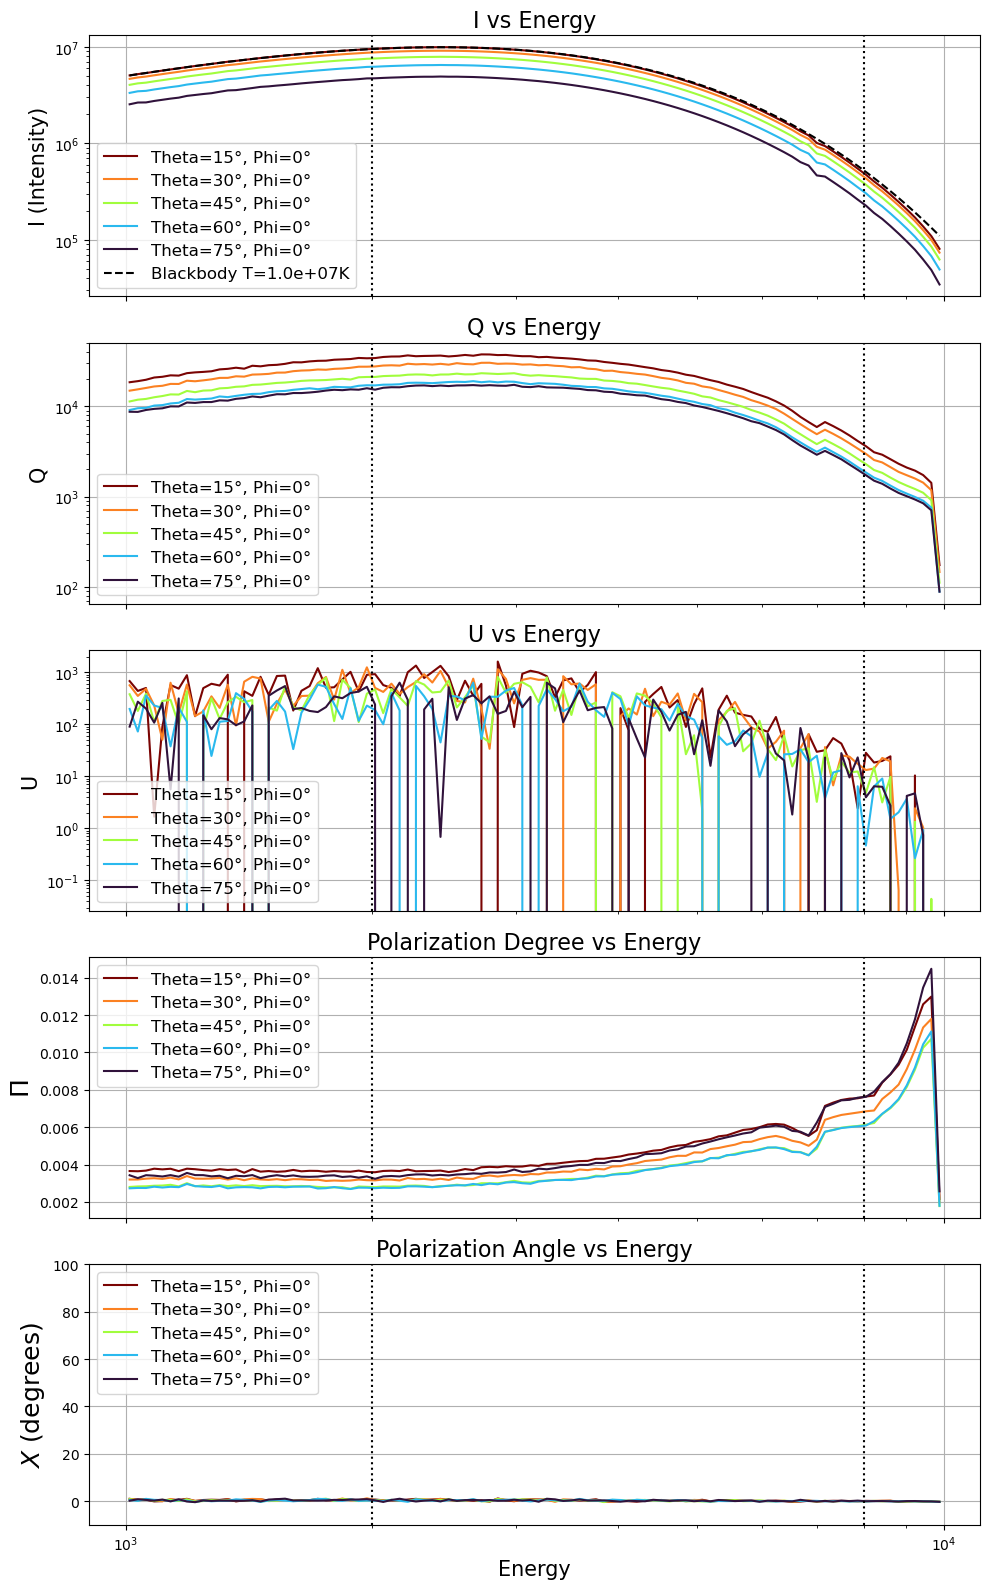

In [17]:
def compute_total_stokes_integrated_reverse_projection(all_merged_data, theta_observer_deg, phi_observer_deg):
    degree_values = sorted(all_merged_data.keys())
    theta_wind_rad = np.radians(degree_values)
    phi_wind_vals = np.linspace(0, 360, 100, endpoint=False)
    phi_wind_rad = np.radians(phi_wind_vals)

    energy_bins = next(iter(all_merged_data[degree_values[0]].values()))["Energy"].values
    n_energy = len(energy_bins)
    
    interpolated_I_list, interpolated_Q_list, interpolated_U_list = [], [], []

    for phi_wind in phi_wind_vals:
        print(f"\n[REVERSE] Processing phi_wind = {phi_wind}")
        I_theta, Q_theta, U_theta = [], [], []

        for theta_wind in degree_values:
            cosT_s, phi_s = observer_to_local_cosT_P_z_ref(theta_observer_deg, phi_observer_deg, theta_wind, phi_wind)
            #print(f"  [REVERSE] theta_wind = {theta_wind}, cosT_s = {cosT_s:.4f}, phi_s = {phi_s:.2f}")
            #print(f"  [REVERSE] theta_wind = {theta_wind}")
            df_candidates = all_merged_data[theta_wind]
            grid_points, I_vals, Q_vals, U_vals = [], [], [], []

            for (cosT_key, P_key), df in df_candidates.items():
                grid_points.append([cosT_key, P_key])
                I_vals.append(df["I"].values)
                Q_vals.append(df["Q"].values)
                U_vals.append(df["U"].values)
                
                #print("I values:",I_vals[0][:10])
                #print("Q values:",Q_vals[0][:10])
                #print("U values:",U_vals[0][:10])

            if not grid_points:
                print(f"    [REVERSE] No valid grid points for theta_wind={theta_wind}, phi_wind={phi_wind}")
                continue

            grid_points = np.array(grid_points)
            I_vals, Q_vals, U_vals = map(np.array, [I_vals, Q_vals, U_vals])

            #interp_I_vals, interp_Q_vals, interp_U_vals = [], [], []
            
            #print("I values:",I_vals[0][:10])
            #print("Q values:",Q_vals[0][:10])
            #print("U values:",U_vals[0][:10])
            
            #print(f"    [REVERSE] Total interpolation points for theta_wind={theta_wind}: {len(grid_points)}")
            
            if cosT_s <= 0:
                interp_I_vals = [0.0] * n_energy
                interp_Q_vals = [0.0] * n_energy
                interp_U_vals = [0.0] * n_energy
            else:
                interp_I_vals, interp_Q_vals, interp_U_vals = [], [], []
                
                for e in range(n_energy):
            
                    I_val = LinearNDInterpolator(grid_points, I_vals[:, e])([cosT_s, phi_s])
                    if np.isnan(I_val):
                        I_val = NearestNDInterpolator(grid_points, I_vals[:, e])([cosT_s, phi_s])

                    Q_val = LinearNDInterpolator(grid_points, Q_vals[:, e])([cosT_s, phi_s])
                    if np.isnan(Q_val):
                        Q_val = NearestNDInterpolator(grid_points, Q_vals[:, e])([cosT_s, phi_s])

                    U_val = LinearNDInterpolator(grid_points, U_vals[:, e])([cosT_s, phi_s])
                    if np.isnan(U_val):
                        U_val = NearestNDInterpolator(grid_points, U_vals[:, e])([cosT_s, phi_s])
                        
                    interp_I_vals.append(I_val if np.isscalar(I_val) else I_val.item())
                    interp_Q_vals.append(Q_val if np.isscalar(Q_val) else Q_val.item())
                    interp_U_vals.append(U_val if np.isscalar(U_val) else U_val.item())
                    
                    #if e == 10:
                        #print(f"    [REVERSE] Sample energy bin 10: I={I_val}, Q={Q_val}, U={U_val}")

            weight = np.sin(np.radians(theta_wind))
            I_theta.append(np.array(interp_I_vals) * weight)
            Q_theta.append(np.array(interp_Q_vals) * weight)
            U_theta.append(np.array(interp_U_vals) * weight)
        
        print(f"Finished wind phi angle {phi_wind} degrees")
        
        I_phi = trapz(np.array(I_theta), x=theta_wind_rad, axis=0)
        Q_phi = trapz(np.array(Q_theta), x=theta_wind_rad, axis=0)
        U_phi = trapz(np.array(U_theta), x=theta_wind_rad, axis=0)

        interpolated_I_list.append(I_phi)
        interpolated_Q_list.append(Q_phi)
        interpolated_U_list.append(U_phi)

    I_total = trapz(np.array(interpolated_I_list), x=phi_wind_rad, axis=0)
    Q_total = trapz(np.array(interpolated_Q_list), x=phi_wind_rad, axis=0)
    U_total = trapz(np.array(interpolated_U_list), x=phi_wind_rad, axis=0)
    
    #print("Total I:",I_total)
    #print("Total Q:",Q_total)
    #print("Total U:",U_total)

    df_result = pd.DataFrame({
        "Energy": energy_bins,
        "I": np.ravel(I_total),
        "Q": np.ravel(Q_total),
        "U": np.ravel(U_total)
    })

    df_result["P_Degree"] = round(polarization_degree(df_result["I"], df_result["Q"], df_result["U"]), 16)
    df_result["P_Angle"] = round(polarization_angle(df_result["Q"], df_result["U"]), 16)

    return df_result



observer_positions = [(15, 0),(30, 0),(45, 0),(60, 0),(75, 0)]
#observer_positions = [(12,0), (22,0), (32,0), (44,0), (58,0), (72,0), (84,0)]
#observer_positions = [(12,0),(18,0),(24,0),(30,0),(36,0),(45,0),(54,0),(63,0),(72,0),(78,0),(84,0)]

results_list = []
observer_labels = []

for theta_obs, phi_obs in observer_positions:
    print(f"Computing for θ = {theta_obs}, φ = {phi_obs}")
    df = compute_total_stokes_integrated_reverse_projection(all_merged_data, theta_obs, phi_obs)
    results_list.append(df)
    observer_labels.append(f"Theta={theta_obs}°, Phi={phi_obs}°")
    
for label, df in zip(observer_labels, results_list):
    avg_P = np.mean(df["P_Degree"])
    print(f"{label}: avg P_Degree = {avg_P:.5f}")

plot_stokes_results(results_list, observer_labels, show_blackbody=True, temperature_K=10**7)

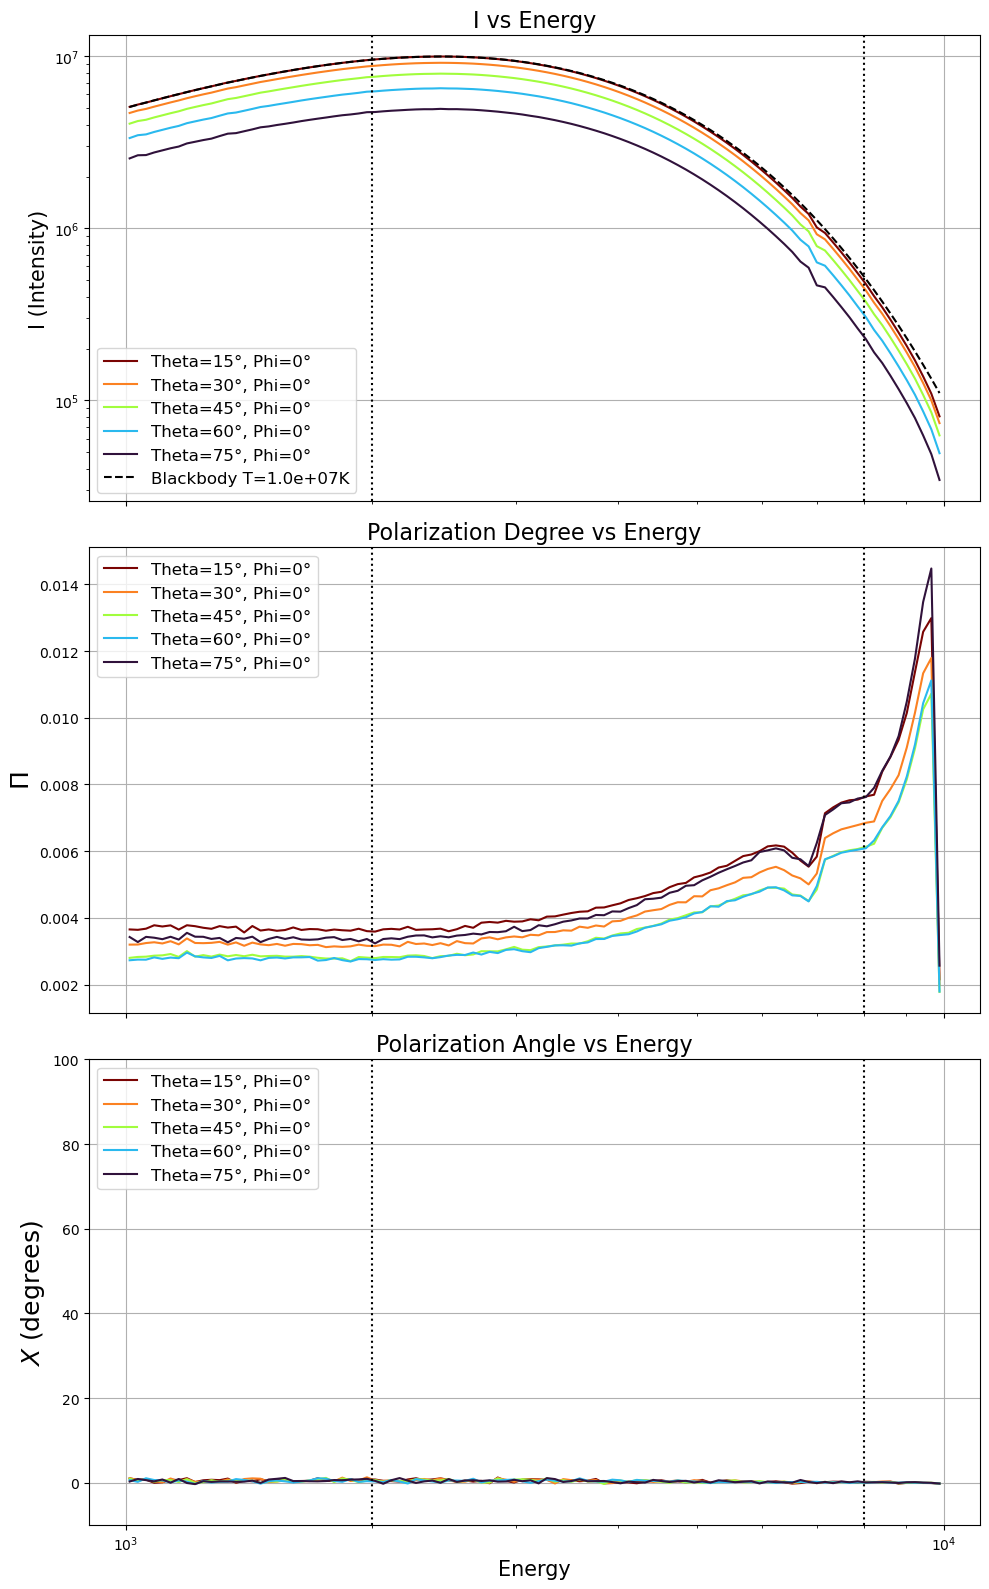

In [21]:
plot_stokes_results(results_list, observer_labels, show_blackbody=True, temperature_K=10**7)

# PLOTTING POL_DEG VS OBSERVER POSITION

Do plots of PolDeg as a function of inclination (but each line integrated over energy 1-10 keV)

In [16]:
theta_obs_list = np.linspace(0, 90, 10)  # 10 angles from 0° to 90° (Change if necessary)
phi_obs = 0  # Change if needed

polarization_results = []

for theta_obs in theta_obs_list:
    df = compute_total_stokes_integrated_reverse_projection(all_merged_data, theta_obs, phi_obs)

    # Mask for my 1–10 keV energy range
    mask = (df["Energy"] >= 1e3) & (df["Energy"] <= 10e3)
    
    I_int = trapz(df["I"][mask], df["Energy"][mask])
    Q_int = trapz(df["Q"][mask], df["Energy"][mask])
    U_int = trapz(df["U"][mask], df["Energy"][mask])
    
    P_deg = polarization_degree(I_int, Q_int, U_int)
    
    polarization_results.append({
        "theta": theta_obs,
        "cos_theta": np.cos(np.radians(theta_obs)),
        "P_Degree": P_deg
    })


[REVERSE] Processing phi_wind = 0.0
Finished wind phi angle 0.0 degrees

[REVERSE] Processing phi_wind = 3.6
Finished wind phi angle 3.6 degrees

[REVERSE] Processing phi_wind = 7.2
Finished wind phi angle 7.2 degrees

[REVERSE] Processing phi_wind = 10.8
Finished wind phi angle 10.8 degrees

[REVERSE] Processing phi_wind = 14.4
Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind 

Finished wind phi angle 7.2 degrees

[REVERSE] Processing phi_wind = 10.8
Finished wind phi angle 10.8 degrees

[REVERSE] Processing phi_wind = 14.4
Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.

Finished wind phi angle 14.4 degrees

[REVERSE] Processing phi_wind = 18.0
Finished wind phi angle 18.0 degrees

[REVERSE] Processing phi_wind = 21.6
Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61

Finished wind phi angle 21.6 degrees

[REVERSE] Processing phi_wind = 25.2
Finished wind phi angle 25.2 degrees

[REVERSE] Processing phi_wind = 28.8
Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68

Finished wind phi angle 28.8 degrees

[REVERSE] Processing phi_wind = 32.4
Finished wind phi angle 32.4 degrees

[REVERSE] Processing phi_wind = 36.0
Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75

Finished wind phi angle 36.0 degrees

[REVERSE] Processing phi_wind = 39.6
Finished wind phi angle 39.6 degrees

[REVERSE] Processing phi_wind = 43.2
Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75.60000000000001
Finished wind phi angle 75.60000000000001 degrees

[REVERSE] Processing phi_wind = 79.2
Finished wind phi angle 79.2 degrees

[REVERSE

Finished wind phi angle 43.2 degrees

[REVERSE] Processing phi_wind = 46.800000000000004
Finished wind phi angle 46.800000000000004 degrees

[REVERSE] Processing phi_wind = 50.4
Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75.60000000000001
Finished wind phi angle 75.60000000000001 degrees

[REVERSE] Processing phi_wind = 79.2
Finished wind phi angle 79.2 degrees

[REVERSE] Processing phi_wind = 82.8
Finished wind phi angle 82.8 degrees

[REVERSE] Processing phi_wind = 86.4
Finished wind phi angle 86.4 degrees

[REVERSE

Finished wind phi angle 50.4 degrees

[REVERSE] Processing phi_wind = 54.0
Finished wind phi angle 54.0 degrees

[REVERSE] Processing phi_wind = 57.6
Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75.60000000000001
Finished wind phi angle 75.60000000000001 degrees

[REVERSE] Processing phi_wind = 79.2
Finished wind phi angle 79.2 degrees

[REVERSE] Processing phi_wind = 82.8
Finished wind phi angle 82.8 degrees

[REVERSE] Processing phi_wind = 86.4
Finished wind phi angle 86.4 degrees

[REVERSE] Processing phi_wind = 90.0
Finished wind phi angle 90.0 degrees

[REVERSE] Processing phi_wind = 93.60000000000001
Finished wind phi angle 93.60000000000001 degrees

[REVERSE] 

Finished wind phi angle 57.6 degrees

[REVERSE] Processing phi_wind = 61.2
Finished wind phi angle 61.2 degrees

[REVERSE] Processing phi_wind = 64.8
Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75.60000000000001
Finished wind phi angle 75.60000000000001 degrees

[REVERSE] Processing phi_wind = 79.2
Finished wind phi angle 79.2 degrees

[REVERSE] Processing phi_wind = 82.8
Finished wind phi angle 82.8 degrees

[REVERSE] Processing phi_wind = 86.4
Finished wind phi angle 86.4 degrees

[REVERSE] Processing phi_wind = 90.0
Finished wind phi angle 90.0 degrees

[REVERSE] Processing phi_wind = 93.60000000000001
Finished wind phi angle 93.60000000000001 degrees

[REVERSE] Processing phi_wind = 97.2
Finished wind phi angle 97.2 degrees

[REVERSE] Processing phi_wind = 100.8
Finished wind phi angle 100.8 degrees

[REVERSE

Finished wind phi angle 64.8 degrees

[REVERSE] Processing phi_wind = 68.4
Finished wind phi angle 68.4 degrees

[REVERSE] Processing phi_wind = 72.0
Finished wind phi angle 72.0 degrees

[REVERSE] Processing phi_wind = 75.60000000000001
Finished wind phi angle 75.60000000000001 degrees

[REVERSE] Processing phi_wind = 79.2
Finished wind phi angle 79.2 degrees

[REVERSE] Processing phi_wind = 82.8
Finished wind phi angle 82.8 degrees

[REVERSE] Processing phi_wind = 86.4
Finished wind phi angle 86.4 degrees

[REVERSE] Processing phi_wind = 90.0
Finished wind phi angle 90.0 degrees

[REVERSE] Processing phi_wind = 93.60000000000001
Finished wind phi angle 93.60000000000001 degrees

[REVERSE] Processing phi_wind = 97.2
Finished wind phi angle 97.2 degrees

[REVERSE] Processing phi_wind = 100.8
Finished wind phi angle 100.8 degrees

[REVERSE] Processing phi_wind = 104.4
Finished wind phi angle 104.4 degrees

[REVERSE] Processing phi_wind = 108.0
Finished wind phi angle 108.0 degrees

[REV

In [1]:
# Convert to DataFrame for easy plotting
df_plot = pd.DataFrame(polarization_results)

# Plot: polarization degree vs inclination
plt.figure(figsize=(8, 6))
plt.plot(df_plot["cos_theta"], df_plot["P_Degree"], marker='o', linestyle='-', markersize=0, color='darkblue')
plt.xlabel("cos(θ$_{obs}$)", fontsize = 12)
plt.ylabel(r"$\Pi$", fontsize = 14)
plt.title("Polarization Degree vs Observer Inclination", fontsize = 15)
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined